<a href="https://colab.research.google.com/github/zoboro/Python-101/blob/main/9_Matplotlib.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Matplotlib
Matplotlib is a library for creating static, interactive, and animated visualizations in Python.
* Matplotlib is crucial for data analysis, it offers a way to visualize data and insights in a graphical format.
* Integrates with Pandas and NumPy, easy to go from data manipulation to visualization.

More details on the [charts](https://matplotlib.org/stable/plot_types/index.html).

In [1]:
##Importing and Loading Data

from google.colab import userdata
from huggingface_hub import login
login(userdata.get("Data-jobs"))

# Loading Data
import pandas as pd
import matplotlib.pyplot as plt  # we will use this for plotting

df = pd.read_csv("hf://datasets/lukebarousse/data_jobs/data_jobs.csv")

In [2]:
##Data Cleanup

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

##Plotting Graphs


###Simple Plot

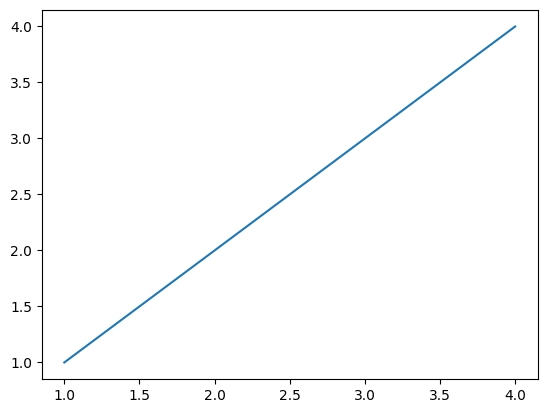

In [3]:
x = [1, 2, 3, 4]
y = [1, 2, 3, 4]

plt.plot(x, y)

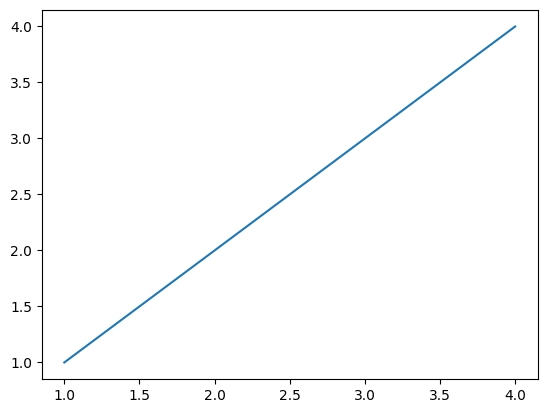

In [4]:
x = [1, 2, 3, 4]
y = [1, 2, 3, 4]

plt.plot(x, y)
plt.show()

###Line Graph
* `plot()` is used to draw points in a diagram.
* The default draws a line from point to point.
* It takes parameters for specifying points in the graph.
    * First parameter is the x-axis.
    * Second parameter is the y-axis.
    * Like this: plt.plot(x-axis,y-axis).

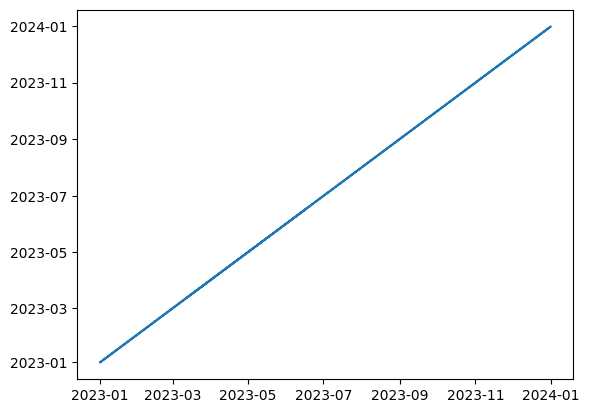

In [5]:
plt.plot(df['job_posted_date'], df['job_posted_date'])

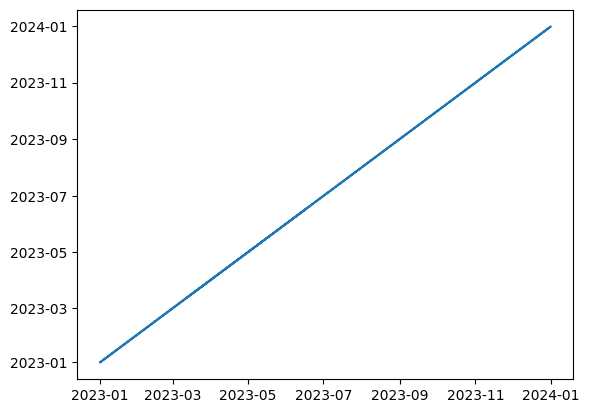

In [6]:
plt.plot('job_posted_date','job_posted_date',data=df)

In [7]:
date_counts = df['job_posted_date'].value_counts()

date_counts = date_counts.sort_index()

date_counts

,count
job_posted_date,
2023-01-01 00:00:04,1
2023-01-01 00:00:07,1
2023-01-01 00:00:22,1
2023-01-01 00:00:24,1
2023-01-01 00:00:27,1
...,...
2023-12-31 23:40:18,2
2023-12-31 23:40:22,2
2023-12-31 23:40:31,2


This `date_counts` acts as a `Series` not `Dataframe`

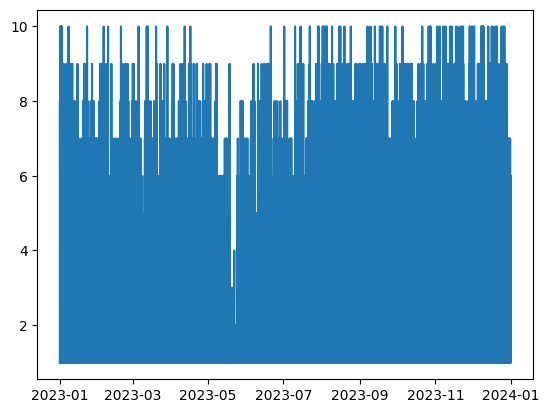

In [8]:
plt.plot(date_counts.index, date_counts)

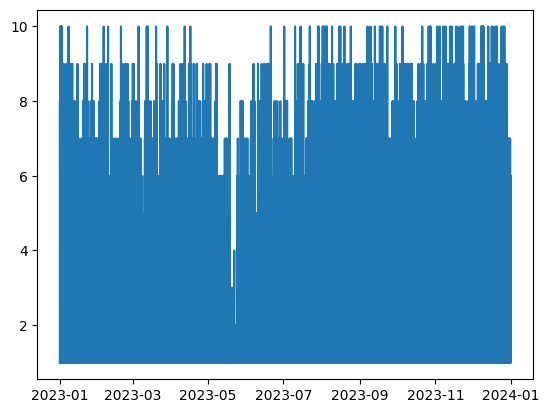

In [9]:
plt.plot(date_counts.index, date_counts.values)

In [10]:
# Assuming 'job_posted_date' is already converted to datetime format in the original df
df['job_posted_month'] = df['job_posted_date'].dt.month

# Group by 'month' and count the job postings
monthly_counts = df['job_posted_month'].value_counts()

# Sort the months
monthly_counts = monthly_counts.sort_index()

monthly_counts

,count
job_posted_month,
1,91822
2,64578
3,64084
4,62919
5,52104
6,61572
7,63777
8,75162
9,62359


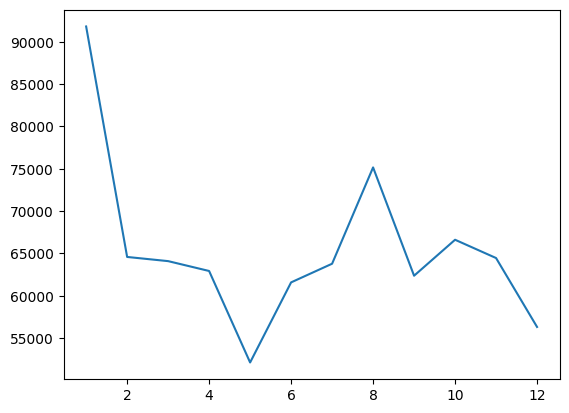

In [11]:
plt.plot(monthly_counts.index, monthly_counts)

###Bar Charts
Used to compare different groups or to track changes over time.

Best for categorical data comparison.

####Bar Plot
* `plt.bar()` for vertical bar plots.
* Syntax: `plt.bar(categories, values)`
* The bars are vertical.

<BarContainer object of 10 artists>

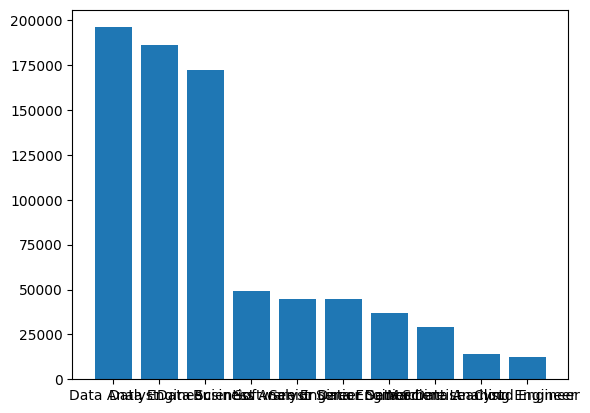

In [14]:
# Get the value counts of the job titles for the filtered DataFrame
job_counts = df['job_title_short'].value_counts()

plt.bar(job_counts.index, job_counts.values)

<BarContainer object of 3 artists>

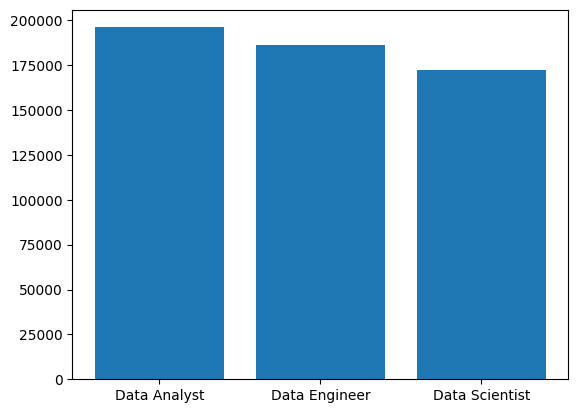

In [13]:
# Get the value counts of the job titles for the filtered DataFrame
job_counts = df['job_title_short'].value_counts().head(3) # Only top 3

# Plot the job counts
plt.bar(job_counts.index, job_counts.values)

####Horizontal Bar Plot
* This is similar to a bar chart but the bars are horizontal.
* Even the syntax is similar: `plt.barh(categories, values)`.
* It's useful when chart labels are lengthy (like in our previous example.

In [19]:
# Get the value counts of the job titles for the filtered DataFrame
job_counts = (
    df['job_title_short']
    .value_counts()
    .sort_values(ascending=True)
)

job_counts

,count
job_title_short,
Cloud Engineer,12331
Machine Learning Engineer,14080
Senior Data Analyst,29216
Senior Data Scientist,36957
Senior Data Engineer,44563
Software Engineer,44929
Business Analyst,49063
Data Scientist,172286
Data Engineer,186241


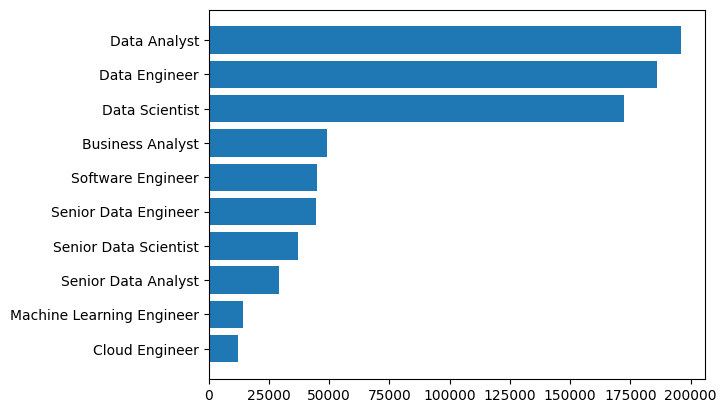

In [17]:
plt.barh(job_counts.index, job_counts)  # Changed this to be a horizontal bar chart instead
plt.show()

##Labelling
Labels are text descriptions added to a chart to make it understandable.
* `title()` - Set a title for the graph
* `xlabel()` - Set the labels of the x-axis
* `ylabel()` - Set the labels of the y-axis
* `rotation` - rotate the label by X amount of degrees e.g. plt.xticks(rotation=45) to rotate the x-axis labels by 45 degrees
* `xticks()` - Customize the x-axis
* `yticks()` - Customize the y-axis


<BarContainer object of 10 artists>

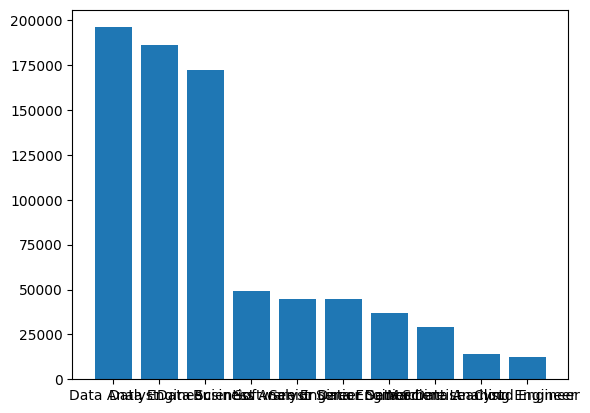

In [20]:
job_counts = df['job_title_short'].value_counts()

# Original Plot
plt.bar(job_counts.index, job_counts)

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'Data Analyst'),
  Text(1, 0, 'Data Engineer'),
  Text(2, 0, 'Data Scientist'),
  Text(3, 0, 'Business Analyst'),
  Text(4, 0, 'Software Engineer'),
  Text(5, 0, 'Senior Data Engineer'),
  Text(6, 0, 'Senior Data Scientist'),
  Text(7, 0, 'Senior Data Analyst'),
  Text(8, 0, 'Machine Learning Engineer'),
  Text(9, 0, 'Cloud Engineer')])

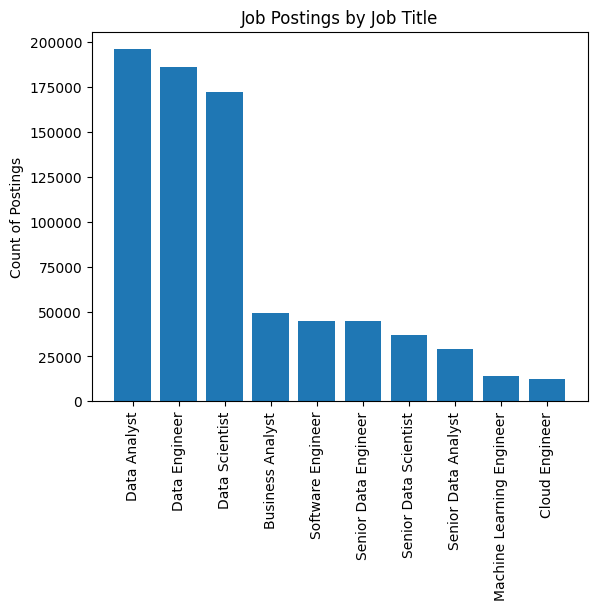

In [22]:
plt.bar(job_counts.index, job_counts)
plt.ylabel('Count of Postings') # no xlabel required as I feel it's self explanatory
plt.title('Job Postings by Job Title')
plt.xticks(rotation=90)

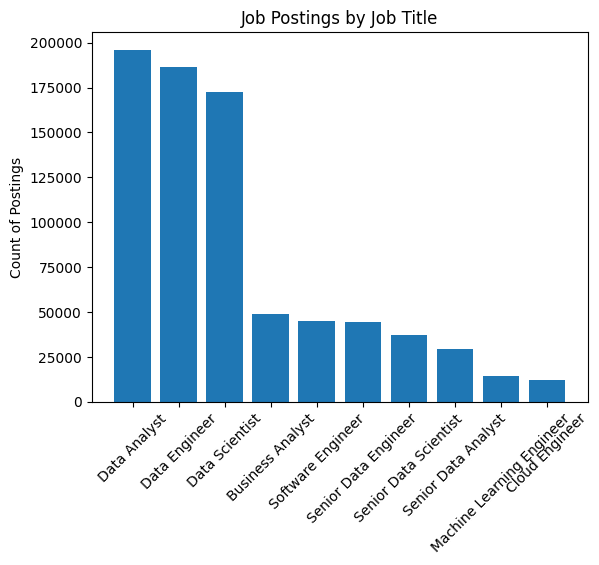

In [23]:
plt.bar(job_counts.index, job_counts)
plt.ylabel('Count of Postings')
plt.title('Job Postings by Job Title')
plt.xticks(rotation=45)
plt.show()

The x labels are all jacked up let's fix this using the arguements `ha` and `va` in the `.xticks()` method.
* `ha='right'`: Aligns the right edge of the label with the tick mark, which compensates for the rotation and helps center the label.
* `va='top'`: Adjusts the vertical alignment to keep the text above the tick mark and prevent it from overlapping with the x-axis.

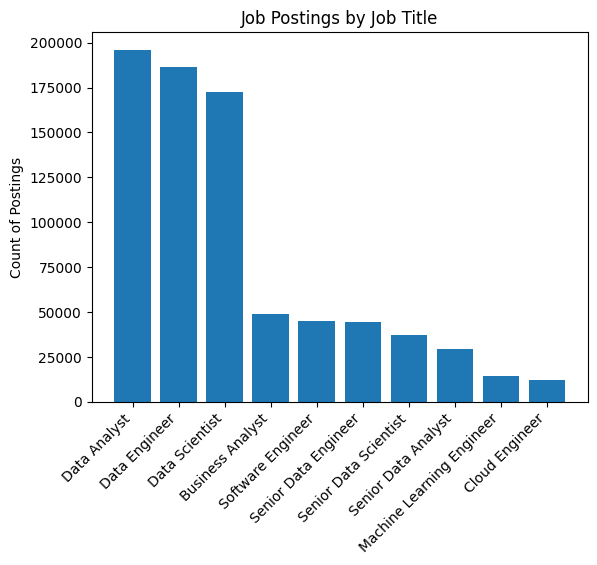

In [29]:
plt.bar(job_counts.index, job_counts)
plt.ylabel('Count of Postings')
plt.title('Job Postings by Job Title')
plt.xticks(rotation=45,ha='right')
plt.show()